# Power Demand Forecasting
loading PGCB power data, weather and economic indicators, merging them and building a few models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
# loading the 3 datasets
df = pd.read_excel('/content/PGCB_date_power_demand.xlsx')
df_weather = pd.read_excel('/content/weather_data.xlsx', skiprows=2)
df_economic = pd.read_csv('/content/economic_full_1.csv')


In [3]:
display(df_economic.head())


,Country Name,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,X,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,X,Battle-related deaths (number of people),VC.BTL.DETH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,41.000000,47.000000,NaN,NaN,2.000000,NaN,2.000000,NaN,2.000000,NaN
2,X,Voice and Accountability: Percentile Rank,VA.PER.RNK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.541872,30.049261,27.184465,26.570047,26.570047,28.019323,28.019323,27.450981,NaN,NaN
3,X,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.820301,21.484188,22.048898,19.559759,22.257010,27.162699,25.520411,17.176637,23.495141,NaN
4,X,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,64.068305,57.202109,62.313903,63.578283,67.395621,64.565856,63.537174,67.817057,65.566600,NaN


In [4]:
display(df_weather.head())
df_weather.shape


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
1,2014-01-01 00:00:00,13.9,89,13.3,0,12.1,16.4,313,0,0
2,2014-01-01 01:00:00,13.6,91,13.2,0,12.1,16,317,0,0
3,2014-01-01 02:00:00,13.3,91,12.8,0,11.9,15.7,317,0,0
4,2014-01-01 03:00:00,13,92,12.5,0,11.8,15.4,319,0,0


(107305, 10)

In [5]:
display(df.head())
df.shape


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


(92650, 15)

In [6]:
# only keeping relevent economic indicators
ImportantFeatures = [
    'Population, total',
    'Urban population (% of total population)',
    'GDP per capita (constant 2015 US$)',
    'GDP growth (annual %)',
    'Access to electricity (% of population)'
]

x_econ = df_economic[df_economic['Indicator Name'].isin(ImportantFeatures)].copy()
year_cols = [col for col in x_econ.columns if str(col).isdigit()]

# melt then pivot to get year-wise rows
x_melted = x_econ.melt(
    id_vars=['Indicator Name'],
    value_vars=year_cols,
    var_name='year',
    value_name='value'
)

x_pivot = x_melted.pivot(
    index='year',
    columns='Indicator Name',
    values='value'
).reset_index()

x_pivot['year'] = pd.to_numeric(x_pivot['year'], errors='coerce')
x_pivot.columns = ['year', 'access_to_elec', 'gdp_growth', 'gdp_per_capita', 'pop_total', 'urban_pop_pct']
x_pivot = x_pivot.dropna(subset=['year']).sort_values('year')

display(x_pivot.head())


,year,access_to_elec,gdp_growth,gdp_per_capita,pop_total,urban_pop_pct
0,1960,NaN,NaN,429.398701,51828660.0,5.112178
1,1961,NaN,6.058161,442.754803,53310348.0,5.277111
2,1962,NaN,5.453031,453.534881,54881146.0,5.465581
3,1963,NaN,-0.455894,438.497510,56504402.0,5.656050
4,1964,NaN,10.952789,472.526378,58178374.0,5.854935


In [7]:
# weather file had a extra header row, need to fix that
df_weather.columns = df_weather.iloc[0]
df_weather = df_weather[1:]

df_weather = df_weather.rename(columns={'time': 'datetime'})
df_weather['datetime'] = pd.to_datetime(df_weather['datetime'], errors='coerce')

# parse main df datetime too
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

display(df_weather.head())
print(df['datetime'].dtype)
display(df.head())


,datetime,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
1,2014-01-01 00:00:00,13.9,89,13.3,0,12.1,16.4,313,0,0
2,2014-01-01 01:00:00,13.6,91,13.2,0,12.1,16,317,0,0
3,2014-01-01 02:00:00,13.3,91,12.8,0,11.9,15.7,317,0,0
4,2014-01-01 03:00:00,13,92,12.5,0,11.8,15.4,319,0,0
5,2014-01-01 04:00:00,12.7,93,12.2,0,11.6,15.2,322,0,0


datetime64[ns]


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


In [8]:
# pull year from datetime then merge economic data
df['year'] = df['datetime'].dt.year
df = df.merge(x_pivot, on='year', how='left')

# merge weather on exact hour
df = df.merge(df_weather, on='datetime', how='left')

print('Shape after merging:', df.shape)
display(df.head())


Shape after merging: (92650, 30)


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,urban_pop_pct,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,...,29.53951,26,91,31,0,24.4,27.3,95,42,0
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,...,29.53951,26.2,90,31.2,0,24.4,27.5,90,84,0
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,...,29.53951,27.3,85,32.4,0.2,24.6,28.7,97,41,0
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,...,29.53951,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,...,29.53951,28.3,81,33.9,0.2,24.8,29.8,108,40,3600


In [9]:
# sort chronologically before shifting
df = df.sort_values('datetime').reset_index(drop=True)

df['demand_lag_1h'] = df['demand_mw'].shift(1)
df['demand_lag_24h'] = df['demand_mw'].shift(24)
# 1 week lag
df['demand_lag_168h'] = df['demand_mw'].shift(168)

display(df[['datetime', 'demand_mw', 'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h']].head(5))
display(df[['datetime', 'demand_mw', 'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h']].tail(5))


,datetime,demand_mw,demand_lag_1h,demand_lag_24h,demand_lag_168h
0,2015-04-19 00:00:00,4821,NaN,NaN,NaN
1,2015-04-19 01:00:00,3612,4821.0,NaN,NaN
2,2015-04-19 02:00:00,3727,3612.0,NaN,NaN
3,2015-04-19 03:00:00,3632,3727.0,NaN,NaN
4,2015-04-19 04:00:00,3641,3632.0,NaN,NaN


,datetime,demand_mw,demand_lag_1h,demand_lag_24h,demand_lag_168h
92645,2025-06-17 08:00:00,11896,11745.0,13155.0,12403.0
92646,2025-06-17 09:00:00,12290,11896.0,13569.0,12072.0
92647,2025-06-17 10:00:00,12443,12290.0,13816.0,11377.0
92648,2025-06-17 11:00:00,12826,12443.0,14226.0,12660.0
92649,2025-06-17 12:00:00,13139,12826.0,14125.0,13280.0


In [10]:
# time based features from datetime
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
# fri/sat are weekends in Bangladesh
df['is_weekend'] = df['datetime'].dt.dayofweek.isin([4, 5]).astype(int)

display(df[['datetime', 'hour', 'day_of_week', 'month', 'is_weekend']].head())


,datetime,hour,day_of_week,month,is_weekend
0,2015-04-19 00:00:00,0,6,4,0
1,2015-04-19 01:00:00,1,6,4,0
2,2015-04-19 02:00:00,2,6,4,0
3,2015-04-19 03:00:00,3,6,4,0
4,2015-04-19 04:00:00,4,6,4,0


In [11]:
# encode day/evening peak from the remarks col
df['is_day_peak'] = df['remarks'].str.contains('Day_Peak', case=False, na=False).astype(int)
df['is_evening_peak'] = df['remarks'].str.contains('Evening_Peak', case=False, na=False).astype(int)

df = df.drop(columns=['remarks'])
display(df[['datetime', 'is_day_peak', 'is_evening_peak']].head(10))


,datetime,is_day_peak,is_evening_peak
0,2015-04-19 00:00:00,0,0
1,2015-04-19 01:00:00,0,0
2,2015-04-19 02:00:00,0,0
3,2015-04-19 03:00:00,0,0
4,2015-04-19 04:00:00,0,0
5,2015-04-19 05:00:00,0,0
6,2015-04-19 06:00:00,0,0
7,2015-04-19 07:00:00,0,0
8,2015-04-19 08:00:00,0,0
9,2015-04-19 09:00:00,0,0


In [12]:
df.columns.tolist()


['datetime',
 'generation_mw',
 'demand_mw',
 'load_shedding',
 'gas',
 'liquid_fuel',
 'coal',
 'hydro',
 'solar',
 'wind',
 'india_bheramara_hvdc',
 'india_tripura',
 'india_adani',
 'nepal',
 'year',
 'access_to_elec',
 'gdp_growth',
 'gdp_per_capita',
 'pop_total',
 'urban_pop_pct',
 'temperature_2m (°C)',
 'relative_humidity_2m (%)',
 'apparent_temperature (°C)',
 'precipitation (mm)',
 'dew_point_2m (°C)',
 'soil_temperature_0_to_7cm (°C)',
 'wind_direction_10m (°)',
 'cloud_cover (%)',
 'sunshine_duration (s)',
 'demand_lag_1h',
 'demand_lag_24h',
 'demand_lag_168h',
 'hour',
 'day_of_week',
 'month',
 'is_weekend',
 'is_day_peak',
 'is_evening_peak']

In [13]:
# quick check before filling nulls
df = df.sort_values(by='datetime').reset_index(drop=True)

print('Final columns list:')
print(df.columns.tolist())
print('\nMissing values count:')
print(df[['demand_mw', 'demand_lag_1h', 'temperature_2m (°C)', 'hour', 'gdp_per_capita', 'pop_total']].isnull().sum())

display(df.head())


Final columns list:
['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal', 'year', 'access_to_elec', 'gdp_growth', 'gdp_per_capita', 'pop_total', 'urban_pop_pct', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'apparent_temperature (°C)', 'precipitation (mm)', 'dew_point_2m (°C)', 'soil_temperature_0_to_7cm (°C)', 'wind_direction_10m (°)', 'cloud_cover (%)', 'sunshine_duration (s)', 'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_day_peak', 'is_evening_peak']

Missing values count:
demand_mw                 0
demand_lag_1h             1
temperature_2m (°C)    4181
hour                      0
gdp_per_capita         4188
pop_total              4188
dtype: int64


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,sunshine_duration (s),demand_lag_1h,demand_lag_24h,demand_lag_168h,hour,day_of_week,month,is_weekend,is_day_peak,is_evening_peak
0,2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,NaN,NaN,...,0,NaN,NaN,NaN,0,6,4,0,0,0
1,2015-04-19 01:00:00,3612.0,3612,0,0,0,0,0,NaN,NaN,...,0,4821.0,NaN,NaN,1,6,4,0,0,0
2,2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,NaN,NaN,...,0,3612.0,NaN,NaN,2,6,4,0,0,0
3,2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,NaN,NaN,...,0,3727.0,NaN,NaN,3,6,4,0,0,0
4,2015-04-19 04:00:00,3641.0,3641,0,0,0,0,0,NaN,NaN,...,0,3632.0,NaN,NaN,4,6,4,0,0,0


In [14]:
cols_fill_special = ['solar', 'wind', 'india_adani', 'nepal', 'gdp_per_capita', 'pop_total']

cols_to_interpolate = [
    'temperature_2m (°C)', 'relative_humidity_2m (%)', 'apparent_temperature (°C)',
    'precipitation (mm)', 'dew_point_2m (°C)', 'soil_temperature_0_to_7cm (°C)',
    'wind_direction_10m (°)', 'cloud_cover (%)', 'sunshine_duration (s)'
]

# convert to numeric first, interpolation breaks on object cols
for col in cols_to_interpolate:
    df[col] = pd.to_numeric(df[col], errors='coerce')

mask_2015_onwards = df['year'] >= 2015

# ffill post-2015, fill rest with 0
for col in cols_fill_special:
    df.loc[mask_2015_onwards, col] = df.loc[mask_2015_onwards, col].ffill().fillna(0)

df[cols_to_interpolate] = df[cols_to_interpolate].interpolate(method='linear', limit_direction='both')

display(df.head())
display(df.tail())


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,sunshine_duration (s),demand_lag_1h,demand_lag_24h,demand_lag_168h,hour,day_of_week,month,is_weekend,is_day_peak,is_evening_peak
0,2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,0.0,0.0,...,0.0,NaN,NaN,NaN,0,6,4,0,0,0
1,2015-04-19 01:00:00,3612.0,3612,0,0,0,0,0,0.0,0.0,...,0.0,4821.0,NaN,NaN,1,6,4,0,0,0
2,2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,0.0,0.0,...,0.0,3612.0,NaN,NaN,2,6,4,0,0,0
3,2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,0.0,0.0,...,0.0,3727.0,NaN,NaN,3,6,4,0,0,0
4,2015-04-19 04:00:00,3641.0,3641,0,0,0,0,0,0.0,0.0,...,0.0,3632.0,NaN,NaN,4,6,4,0,0,0


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,sunshine_duration (s),demand_lag_1h,demand_lag_24h,demand_lag_168h,hour,day_of_week,month,is_weekend,is_day_peak,is_evening_peak
92645,2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,...,1306.80,11745.0,13155.0,12403.0,8,1,6,0,0,0
92646,2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,...,3600.00,11896.0,13569.0,12072.0,9,1,6,0,0,0
92647,2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,...,3600.00,12290.0,13816.0,11377.0,10,1,6,0,0,0
92648,2025-06-17 11:00:00,12826.0,12826,0,5896,595,3591,172,324.0,37.0,...,2629.18,12443.0,14226.0,12660.0,11,1,6,0,1,0
92649,2025-06-17 12:00:00,13139.0,13139,0,5879,724,3712,172,320.0,53.0,...,3600.00,12826.0,14125.0,13280.0,12,1,6,0,0,0


In [15]:
# rolling means for temp and humidity, 6h and 12h windows
df['rolling_temp_6h'] = df['temperature_2m (°C)'].rolling(window=6, min_periods=1).mean()
df['rolling_temp_12h'] = df['temperature_2m (°C)'].rolling(window=12, min_periods=1).mean()
df['rolling_humidity_6h'] = df['relative_humidity_2m (%)'].rolling(window=6, min_periods=1).mean()
df['rolling_humidity_12h'] = df['relative_humidity_2m (%)'].rolling(window=12, min_periods=1).mean()

display(df[['datetime', 'temperature_2m (°C)', 'rolling_temp_6h', 'rolling_temp_12h',
            'relative_humidity_2m (%)', 'rolling_humidity_6h', 'rolling_humidity_12h']].head(15))


,datetime,temperature_2m (°C),rolling_temp_6h,rolling_temp_12h,relative_humidity_2m (%),rolling_humidity_6h,rolling_humidity_12h
0,2015-04-19 00:00:00,25.7,25.700000,25.700000,87.0,87.000000,87.000000
1,2015-04-19 01:00:00,25.3,25.500000,25.500000,88.0,87.500000,87.500000
2,2015-04-19 02:00:00,24.9,25.300000,25.300000,90.0,88.333333,88.333333
3,2015-04-19 03:00:00,25.0,25.225000,25.225000,90.0,88.750000,88.750000
4,2015-04-19 04:00:00,25.2,25.220000,25.220000,91.0,89.200000,89.200000
5,2015-04-19 05:00:00,24.9,25.166667,25.166667,92.0,89.666667,89.666667
6,2015-04-19 06:00:00,24.3,24.933333,25.042857,96.0,91.166667,90.571429
7,2015-04-19 07:00:00,24.0,24.716667,24.912500,97.0,92.666667,91.375000
8,2015-04-19 08:00:00,24.2,24.600000,24.833333,96.0,93.666667,91.888889
9,2015-04-19 09:00:00,25.9,24.750000,24.940000,87.0,93.166667,91.400000


## EDA
quick look at demand distribution, spike patterns and correlations

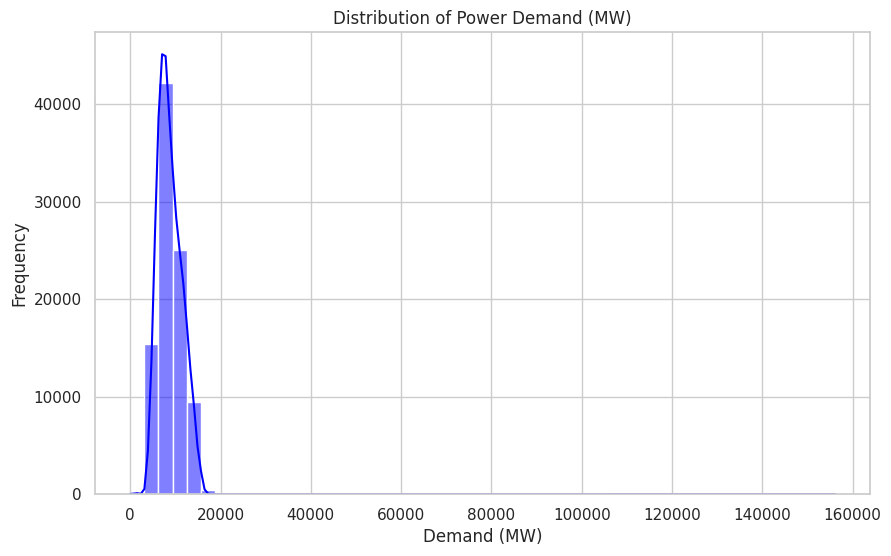

In [16]:
sns.set(style='whitegrid')

plt.figure(figsize=(10, 6))
sns.histplot(df['demand_mw'], kde=True, bins=50, color='blue')
plt.title('Distribution of Power Demand (MW)')
plt.xlabel('Demand (MW)')
plt.ylabel('Frequency')
plt.show()


Demand threshold for spikes: 14363.95 MW
Number of spikes detected: 2266


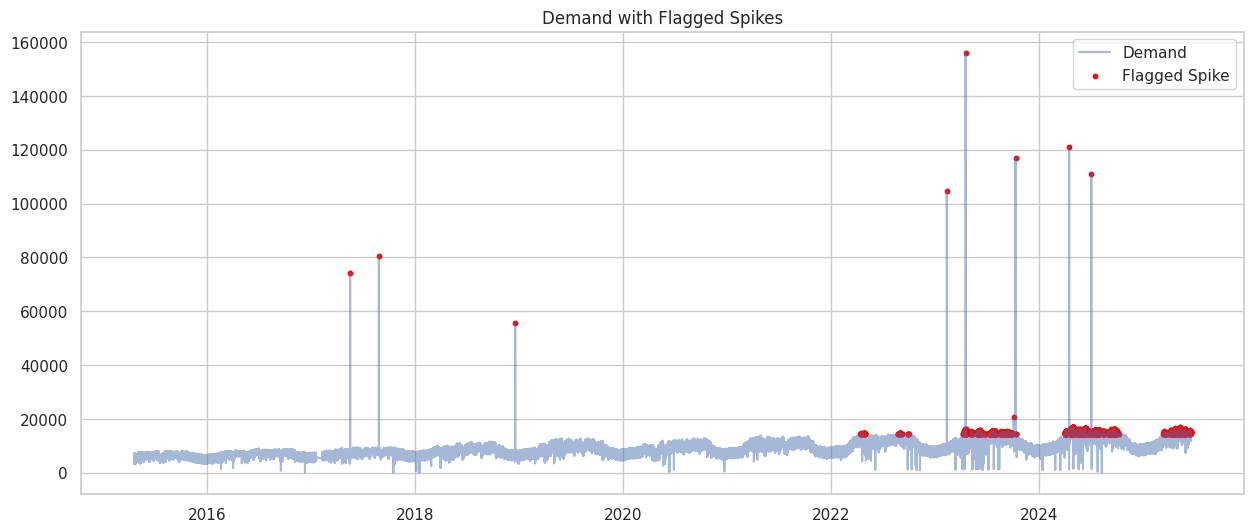

In [17]:
# flag spikes using mean + 2std
threshold = df['demand_mw'].mean() + 2 * df['demand_mw'].std()
df['is_demand_spike'] = (df['demand_mw'] > threshold).astype(int)

print(f'Demand threshold for spikes: {threshold:.2f} MW')
print(f'Number of spikes detected: {df["is_demand_spike"].sum()}')

plt.figure(figsize=(15, 6))
plt.plot(df['datetime'], df['demand_mw'], label='Demand', alpha=0.5)
plt.scatter(df.loc[df['is_demand_spike'] == 1, 'datetime'],
            df.loc[df['is_demand_spike'] == 1, 'demand_mw'],
            color='red', label='Flagged Spike', s=10)
plt.title('Demand with Flagged Spikes')
plt.legend()
plt.show()


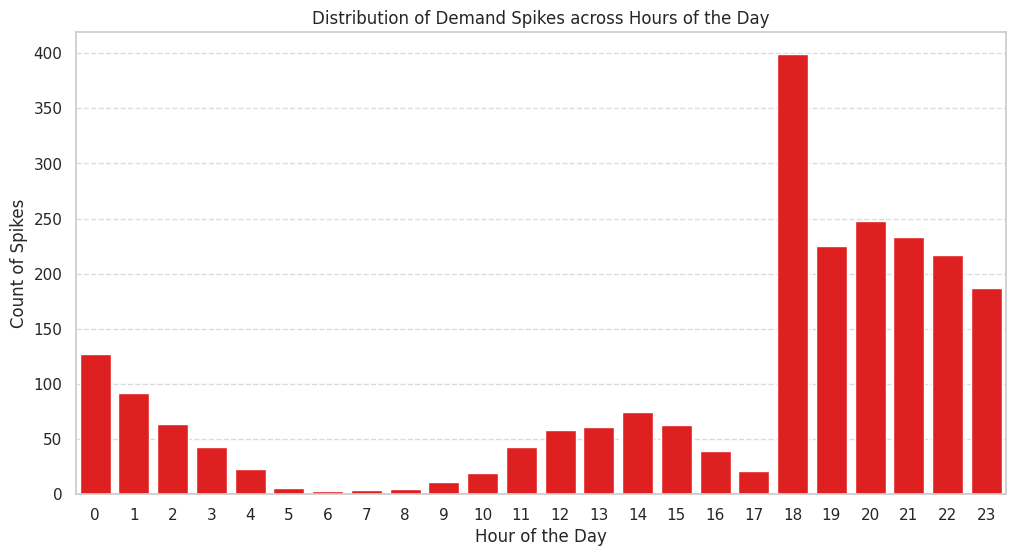

Spike counts per hour:
hour
0     127
1      92
2      64
3      43
4      23
5       6
6       3
7       4
8       5
9      11
10     19
11     43
12     58
13     61
14     75
15     63
16     39
17     21
18    399
19    225
20    248
21    233
22    217
23    187
Name: count, dtype: int64


In [18]:
# see which hours have most spikes
plt.figure(figsize=(12, 6))
sns.countplot(x='hour', data=df[df['is_demand_spike'] == 1], color='red')
plt.title('Distribution of Demand Spikes across Hours of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Count of Spikes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print('Spike counts per hour:')
print(df[df['is_demand_spike'] == 1]['hour'].value_counts().sort_index())


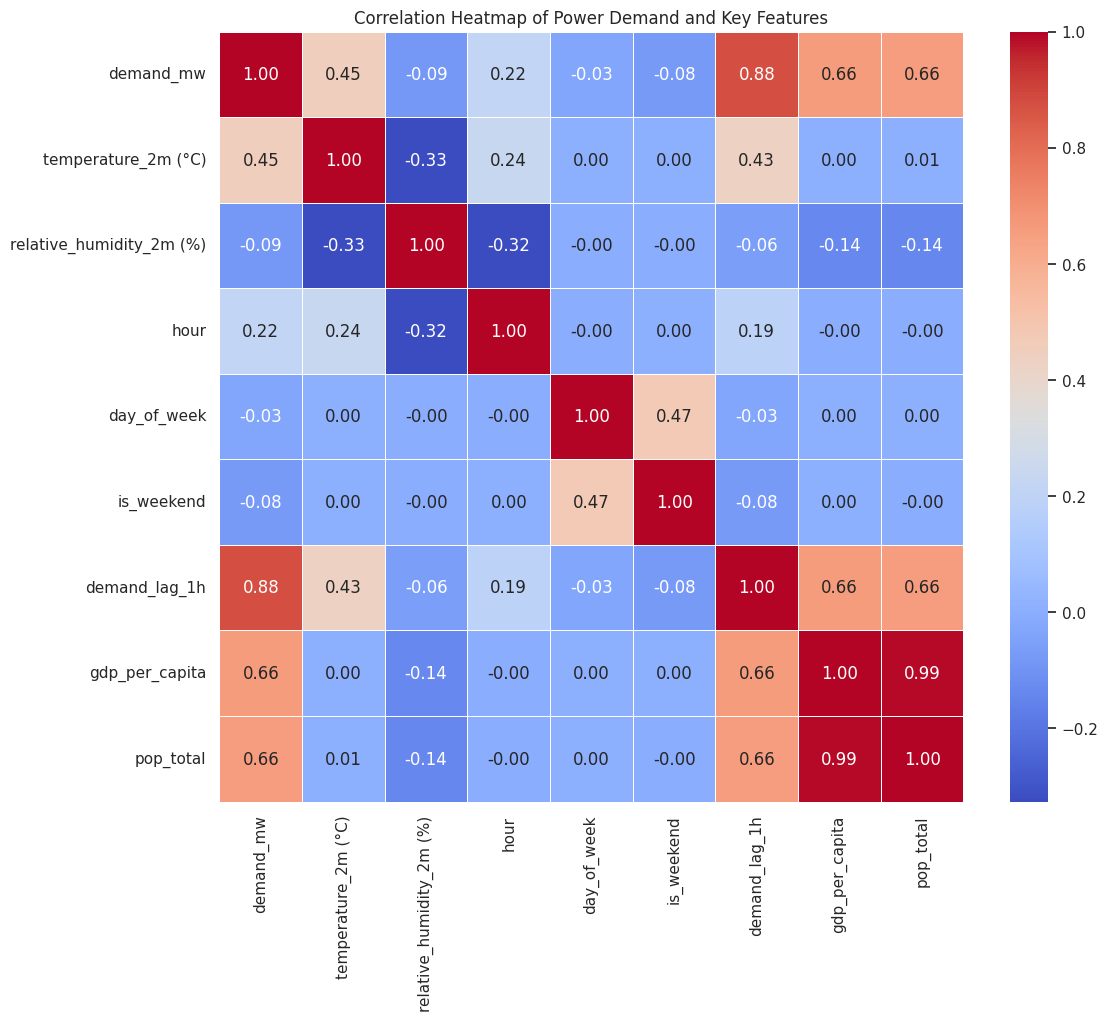

In [19]:
cols_for_corr = [
    'demand_mw', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
    'hour', 'day_of_week', 'is_weekend', 'demand_lag_1h',
    'gdp_per_capita', 'pop_total'
]

# corr heatmap for key features
plt.figure(figsize=(12, 10))
corr_matrix = df[cols_for_corr].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Power Demand and Key Features')
plt.show()


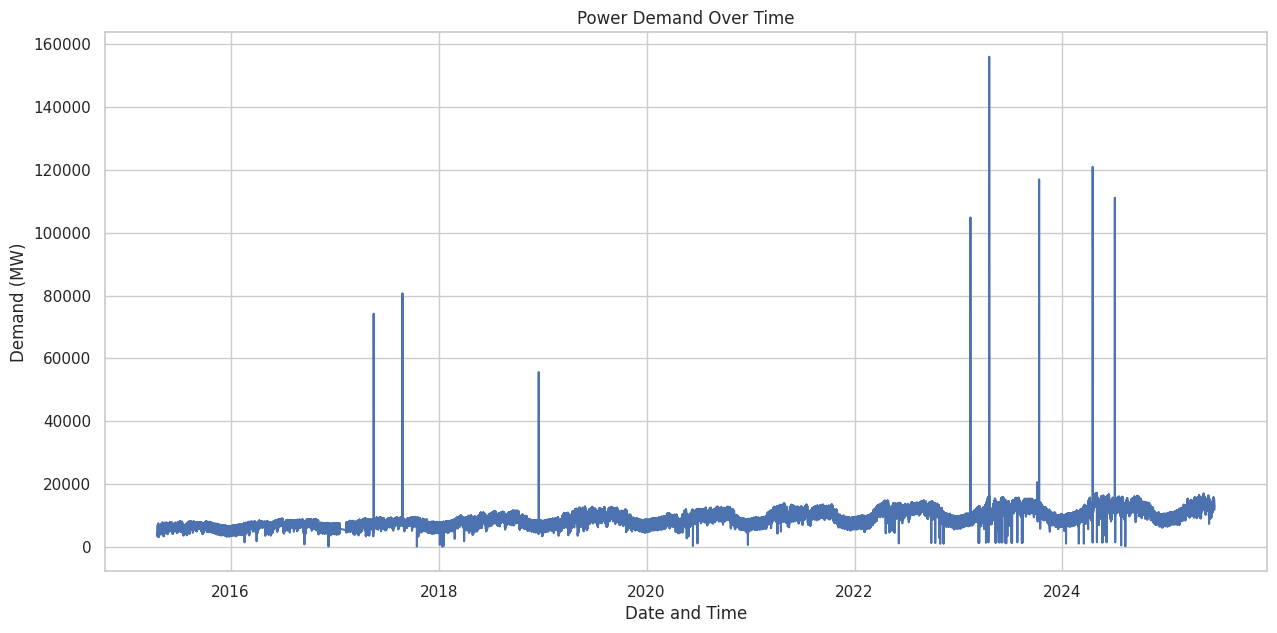

In [20]:
plt.figure(figsize=(15, 7))
sns.lineplot(x='datetime', y='demand_mw', data=df)
plt.title('Power Demand Over Time')
plt.xlabel('Date and Time')
plt.ylabel('Demand (MW)')
plt.grid(True)
plt.show()


## Modelling
trying xgboost, random forest and linear regression. will tune xgboost separately using randomized search

In [21]:
# 80-20 temporal split
split_date = df['datetime'].quantile(0.8)

train = df[df['datetime'] <= split_date].copy()
test = df[df['datetime'] > split_date].copy()

# drop rows where lag cols are NaN
train = train.dropna(subset=['demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h'])

print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')


Train shape: (73952, 43)
Test shape: (18530, 43)


In [22]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error

features = [
    'temperature_2m (°C)', 'relative_humidity_2m (%)', 'apparent_temperature (°C)',
    'precipitation (mm)', 'cloud_cover (%)', 'hour', 'day_of_week', 'month',
    'is_weekend', 'is_day_peak', 'is_evening_peak', 'demand_lag_1h',
    'demand_lag_24h', 'demand_lag_168h', 'gdp_per_capita', 'pop_total',
    'is_demand_spike',
    'rolling_temp_6h', 'rolling_temp_12h', 'rolling_humidity_6h', 'rolling_humidity_12h'
]
target = 'demand_mw'

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    tree_method='hist'
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f'XGBoost Test MAPE (with all features): {mape:.4f} ({mape*100:.2f}%)')


XGBoost Test MAPE (with all features): 0.0464 (4.64%)


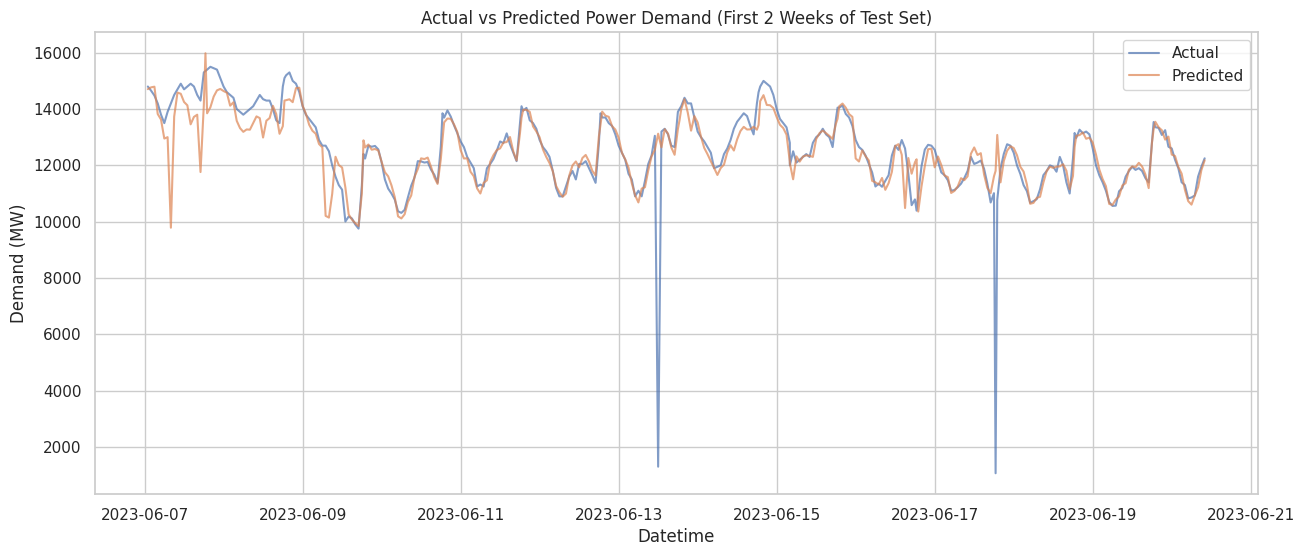

In [23]:
plt.figure(figsize=(15, 6))
plt.plot(test['datetime'].iloc[:336], y_test.iloc[:336], label='Actual', alpha=0.7)
plt.plot(test['datetime'].iloc[:336], y_pred[:336], label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted Power Demand (First 2 Weeks of Test Set)')
plt.xlabel('Datetime')
plt.ylabel('Demand (MW)')
plt.legend()
plt.show()


In [24]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)
print(f'Random Forest Test MAPE: {mape_rf:.4f} ({mape_rf*100:.2f}%)')


Random Forest Test MAPE: 0.0584 (5.84%)


In [25]:
from sklearn.linear_model import LinearRegression

# simple linear baseline
linear_model = LinearRegression(n_jobs=-1)
linear_model.fit(X_train, y_train)

y_pred_lr = linear_model.predict(X_test)
mape_lr = mean_absolute_percentage_error(y_test, y_pred_lr)
print(f'Linear Regression Test MAPE: {mape_lr:.4f} ({mape_lr*100:.2f}%)')


Linear Regression Test MAPE: 0.0594 (5.94%)
